<div style="text-align: center; background: #000; padding: 20px 10px; border-radius: 15px; box-shadow: 0 10px 25px rgba(0,0,0,0.7); font-family: 'Segoe UI', sans-serif; color: white;">

  <div style="position: relative; width: 100%; margin: 0 auto 10px auto;">

<img src="https://i.postimg.cc/QtK78P7J/images.jpg" 
     alt="Water Potability"
     style="
     display: block;
     width: 100%;
     height: auto;
     border-radius: 10px;
     box-shadow: 0 0 10px #666;
     ">


  </div>

</div>

[1. Metadata](#1)<br>
[2. Exploratory Data Analysis](#2)<br>
[3. Data Visualization](#1)<br>

In [2]:
import pandas as pd
import numpy as np
#from ydata_profiling import ProfileReport
from pandas.tseries.holiday import USFederalHolidayCalendar
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
Traffic = pd.read_csv("/kaggle/input/datasets/samanenajarian/traffic/Metro_Interstate_Traffic_Volume.csv")
Traffic = pd.DataFrame(Traffic)
Traffic.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [4]:
Traffic.shape

(48204, 9)

In [5]:
Traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [6]:
Traffic.duplicated().sum()

np.int64(17)

In [7]:
Traffic = Traffic.drop_duplicates()
Traffic.shape

(48187, 9)

<a id="1"></a>
<div style="
    text-align: center;
    background: linear-gradient(90deg, #0B1F3A, #243B73, #4B3F8F);
    padding: 15px;
    border-radius: 10px;
    box-shadow: 0 5px 15px rgba(20, 25, 70, 0.35);
    font-family: 'Segoe UI', sans-serif;
">

  <h2 style="
      color: #D8D6FF;
      font-family: 'Georgia', serif;
      font-weight: bold;
      margin: 0;
      letter-spacing: 1px;
  ">
      Metadata
  </h2>

</div>

In [8]:
#profile_Traffic = ProfileReport(
 #   Traffic, title = "Metro Interstate Traffic Volume"
  #  )

#profile_Traffic.to_file("Metro Interstate Traffic Volume.html")

#profile_Traffic

<div style="
    background: #eef2f7;
    padding: 25px;
    border-radius: 15px;
    box-shadow: 0 6px 18px rgba(0,0,0,0.18);
    font-family: 'Segoe UI', sans-serif;
    color: #1f2937;
">

<h2 style="
    text-align: center;
    color: #1e3a5f;
    margin: 0 0 22px 0;
    font-family: Georgia, 'Times New Roman', serif;
    text-shadow: 1px 1px 2px rgba(0,0,0,0.12);
">
    Metro Interstate Traffic Volume — Feature Metadata
</h2>

<div style="
    display: grid;
    grid-template-columns: repeat(2, 1fr);
    gap: 14px;
">

<div style="background:#ffffff; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; box-shadow:0 2px 6px rgba(0,0,0,0.08);">
    <div style="color:#1e3a5f; font-weight:bold; margin-bottom:6px;">holiday</div>
    <div style="color:#374151;">Indicates whether the observation occurred on a U.S. national holiday or during the Minnesota State Fair.</div>
</div>

<div style="background:#ffffff; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; box-shadow:0 2px 6px rgba(0,0,0,0.08);">
    <div style="color:#1e3a5f; font-weight:bold; margin-bottom:6px;">temp</div>
    <div style="color:#374151;">Average temperature recorded at the time of observation, measured in Kelvin.</div>
</div>

<div style="background:#ffffff; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; box-shadow:0 2px 6px rgba(0,0,0,0.08);">
    <div style="color:#1e3a5f; font-weight:bold; margin-bottom:6px;">rain_1h</div>
    <div style="color:#374151;">Amount of rainfall recorded during the previous hour, measured in millimeters.</div>
</div>

<div style="background:#ffffff; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; box-shadow:0 2px 6px rgba(0,0,0,0.08);">
    <div style="color:#1e3a5f; font-weight:bold; margin-bottom:6px;">snow_1h</div>
    <div style="color:#374151;">Amount of snowfall recorded during the previous hour, measured in millimeters.</div>
</div>

<div style="background:#ffffff; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; box-shadow:0 2px 6px rgba(0,0,0,0.08);">
    <div style="color:#1e3a5f; font-weight:bold; margin-bottom:6px;">clouds_all</div>
    <div style="color:#374151;">Percentage of cloud cover recorded at the time of observation.</div>
</div>

<div style="background:#ffffff; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; box-shadow:0 2px 6px rgba(0,0,0,0.08);">
    <div style="color:#1e3a5f; font-weight:bold; margin-bottom:6px;">weather_main</div>
    <div style="color:#374151;">Short textual description of the prevailing weather condition.</div>
</div>

<div style="background:#ffffff; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; box-shadow:0 2px 6px rgba(0,0,0,0.08);">
    <div style="color:#1e3a5f; font-weight:bold; margin-bottom:6px;">weather_description</div>
    <div style="color:#374151;">Detailed textual description of the prevailing weather condition.</div>
</div>

<div style="background:#ffffff; border:1px solid #b8c2cc; border-left:5px solid #1e3a5f; border-radius:8px; padding:14px 18px; box-shadow:0 2px 6px rgba(0,0,0,0.08);">
    <div style="color:#1e3a5f; font-weight:bold; margin-bottom:6px;">date_time</div>
    <div style="color:#374151;">Date and hour when the observation was recorded in local Central Standard Time (CST).</div>
</div>

<div style="
    background:#f4f7fb;
    border:1px solid #aebdce;
    border-left:5px solid #1e3a5f;
    border-radius:8px;
    padding:14px 18px;
    box-shadow:0 2px 6px rgba(0,0,0,0.08);
">
    <div style="color:#1e3a5f; font-weight:bold; margin-bottom:6px;">traffic_volume</div>
    <div style="color:#374151;">Hourly westbound traffic volume on Interstate 94 (I-94), recorded by ATR Station 301.</div>
</div>

</div>
</div>

<a id="2"></a>
<div style="
    text-align: center;
    background: linear-gradient(90deg, #0B1F3A, #243B73, #4B3F8F);
    padding: 15px;
    border-radius: 10px;
    box-shadow: 0 5px 15px rgba(20, 25, 70, 0.35);
    font-family: 'Segoe UI', sans-serif;
">

  <h2 style="
      color: #D8D6FF;
      font-family: 'Georgia', serif;
      font-weight: bold;
      margin: 0;
      letter-spacing: 1px;
  ">
      Exploratory Data Analysis
  </h2>

</div>

In [9]:
Traffic['date_time'] = pd.to_datetime(Traffic['date_time'])


# ============================================================
# 1. Replace NaN values with U.S. federal holidays
# ============================================================

cal = USFederalHolidayCalendar()

holiday_mapping = {}

for rule in cal.rules:
    dates = rule.dates(
        Traffic['date_time'].min(),
        Traffic['date_time'].max()
    )

    for date in dates:
        holiday_mapping[date.normalize()] = rule.name


# Standardize holiday names
name_mapping = {
    "New Year's Day": "New Years Day",
    "Birthday of Martin Luther King, Jr.": "Martin Luther King Jr Day",
    "Washington's Birthday": "Washingtons Birthday"
}

holiday_mapping = {
    date: name_mapping.get(name, name)
    for date, name in holiday_mapping.items()
}


# Replace only NaN values that fall on federal holidays
mask_h = Traffic['holiday'].isna()

holiday_names = (
    Traffic.loc[mask_h, 'date_time']
    .dt.normalize()
    .map(holiday_mapping)
)

Traffic.loc[mask_h & holiday_names.notna(), 'holiday'] = (
    holiday_names.dropna().values
)

In [10]:
# ============================================================
# 2. Replace remaining NaN values with Minnesota State Fair
# ============================================================

state_fair_dates = pd.to_datetime([
    '2013-08-22',
    '2015-08-27',
    '2016-08-25',
    '2017-08-24',
    '2018-08-23'
])


mask_s = (
    Traffic['holiday'].isna() &
    Traffic['date_time'].dt.normalize().isin(state_fair_dates)
)

Traffic.loc[mask_s, 'holiday'] = 'State Fair'

In [11]:
# ============================================================
# 3. Label remaining NaN values
# ============================================================

Traffic.loc[
    Traffic['holiday'].isna(),
    'holiday'
] = 'Not Holiday'

In [12]:
Traffic['date_time'] = pd.to_datetime(Traffic['date_time'])

Traffic['year'] =Traffic['date_time'].dt.year
Traffic['month'] = Traffic['date_time'].dt.month
Traffic['day'] = Traffic['date_time'].dt.day
Traffic['hour'] = Traffic['date_time'].dt.hour
Traffic = Traffic.drop(columns=['date_time'])

Traffic.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,traffic_volume,year,month,day,hour
0,Not Holiday,288.28,0.0,0.0,40,Clouds,scattered clouds,5545,2012,10,2,9
1,Not Holiday,289.36,0.0,0.0,75,Clouds,broken clouds,4516,2012,10,2,10
2,Not Holiday,289.58,0.0,0.0,90,Clouds,overcast clouds,4767,2012,10,2,11
3,Not Holiday,290.13,0.0,0.0,90,Clouds,overcast clouds,5026,2012,10,2,12
4,Not Holiday,291.14,0.0,0.0,75,Clouds,broken clouds,4918,2012,10,2,13


In [13]:
summary = pd.DataFrame({
    "Description": [
        "Number of variables",
        "Number of observations",
        "Number of categorical variables",
        "Number of continuous variables"
    ],
    "Value": [
        Traffic.shape[1],
        Traffic.shape[0],
        Traffic.select_dtypes(include="object").shape[1],
        Traffic.select_dtypes(include=["int", "float64"]).shape[1]
    ]
})

summary

,Description,Value
0,Number of variables,12
1,Number of observations,48187
2,Number of categorical variables,3
3,Number of continuous variables,9


In [14]:
cat_vars = ['holiday','weather_main','weather_description']
con_vars = ['temp','rain_1h','snow_1h','clouds_all','year','month','day','hour','traffic_volume']

In [15]:
for col in cat_vars:
    print(
        f"Feature: {col} \n"
        f"Number of unique values: {Traffic[col].nunique()}\n"
        f"Unique values: {Traffic[col].unique()}"
)
    
    print("-"*120)

Feature: holiday 
Number of unique values: 12
Unique values: ['Not Holiday' 'Columbus Day' 'Veterans Day' 'Thanksgiving Day'
 'Christmas Day' 'New Years Day' 'Martin Luther King Jr Day'
 'Washingtons Birthday' 'Memorial Day' 'Independence Day' 'State Fair'
 'Labor Day']
------------------------------------------------------------------------------------------------------------------------
Feature: weather_main 
Number of unique values: 11
Unique values: ['Clouds' 'Clear' 'Rain' 'Drizzle' 'Mist' 'Haze' 'Fog' 'Thunderstorm'
 'Snow' 'Squall' 'Smoke']
------------------------------------------------------------------------------------------------------------------------
Feature: weather_description 
Number of unique values: 38
Unique values: ['scattered clouds' 'broken clouds' 'overcast clouds' 'sky is clear'
 'few clouds' 'light rain' 'light intensity drizzle' 'mist' 'haze' 'fog'
 'proximity shower rain' 'drizzle' 'moderate rain' 'heavy intensity rain'
 'proximity thunderstorm' 'thunderst

In [16]:
for var in cat_vars:
    print(f"\n{var}")
    print(Traffic[var].value_counts())
    print("-"*80)


holiday
holiday
Not Holiday                  46723
Labor Day                      157
Independence Day               146
Martin Luther King Jr Day      142
Washingtons Birthday           136
Thanksgiving Day               135
Memorial Day                   134
New Years Day                  131
Christmas Day                  131
Veterans Day                   120
State Fair                     120
Columbus Day                   112
Name: count, dtype: int64
--------------------------------------------------------------------------------

weather_main
weather_main
Clouds          15158
Clear           13384
Mist             5949
Rain             5672
Snow             2875
Drizzle          1820
Haze             1360
Thunderstorm     1033
Fog               912
Smoke              20
Squall              4
Name: count, dtype: int64
--------------------------------------------------------------------------------

weather_description
weather_description
sky is clear                           

In [17]:
Traffic[con_vars].describe()

,temp,rain_1h,snow_1h,clouds_all,year,month,day,hour,traffic_volume
count,48187.000000,48187.000000,48187.000000,48187.000000,48187.000000,48187.000000,48187.000000,48187.000000,48187.000000
mean,281.204995,0.334382,0.000222,49.365451,2015.512047,6.505240,15.736402,11.397742,3259.618134
std,13.338738,44.797033,0.008169,39.015213,1.893393,3.400285,8.721687,6.940373,1986.954465
min,0.000000,0.000000,0.000000,0.000000,2012.000000,1.000000,1.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,2014.000000,4.000000,8.000000,5.000000,1192.500000
50%,282.450000,0.000000,0.000000,64.000000,2016.000000,7.000000,16.000000,11.000000,3379.000000
75%,291.806000,0.000000,0.000000,90.000000,2017.000000,9.000000,23.000000,17.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,2018.000000,12.000000,31.000000,23.000000,7280.000000


<a id="3"></a>
<div style="
    text-align: center;
    background: linear-gradient(90deg, #0B1F3A, #243B73, #4B3F8F);
    padding: 15px;
    border-radius: 10px;
    box-shadow: 0 5px 15px rgba(20, 25, 70, 0.35);
    font-family: 'Segoe UI', sans-serif;
">

  <h2 style="
      color: #D8D6FF;
      font-family: 'Georgia', serif;
      font-weight: bold;
      margin: 0;
      letter-spacing: 1px;
  ">
      Data Visualization
  </h2>

</div>

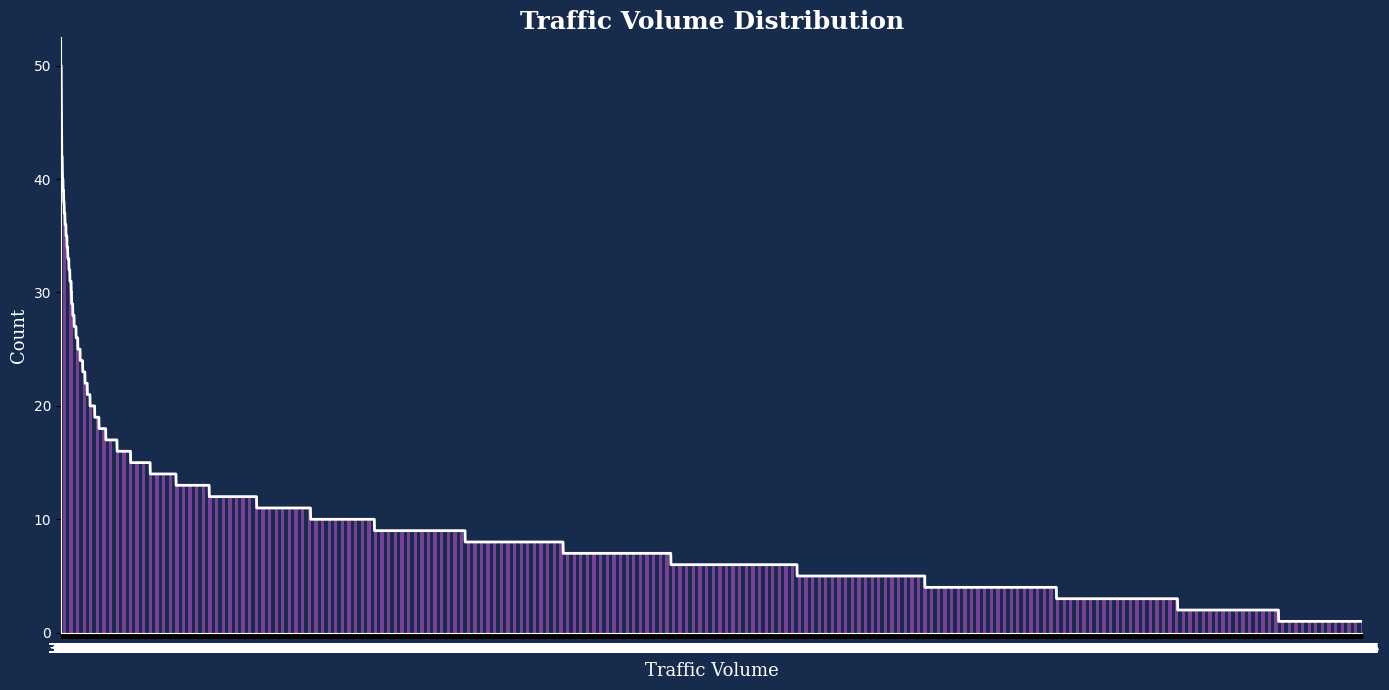

In [18]:
counts = Traffic['traffic_volume'].value_counts()

fig, ax = plt.subplots(figsize=(14, 7), facecolor='#172B4D')
ax.set_facecolor('#172B4D')

counts.plot(
    kind='bar',
    ax=ax,
    color="#7B3F98"
)

plt.plot(
    range(len(counts)),
    counts.values,
    color='white',
    linewidth=2
)

plt.xlabel(
    'Traffic Volume',
    fontsize=13,
    fontfamily='serif',
    color='white'
)

plt.ylabel(
    'Count',
    fontsize=13,
    fontfamily='serif',
    color='white'
)

plt.title(
    'Traffic Volume Distribution',
    fontsize=18,
    fontweight='bold',
    fontfamily='serif',
    color='white'
)

plt.xticks(rotation=0, color='white')
plt.yticks(color='white')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('white')
ax.spines['bottom'].set_color('white')

plt.tight_layout()
plt.show()

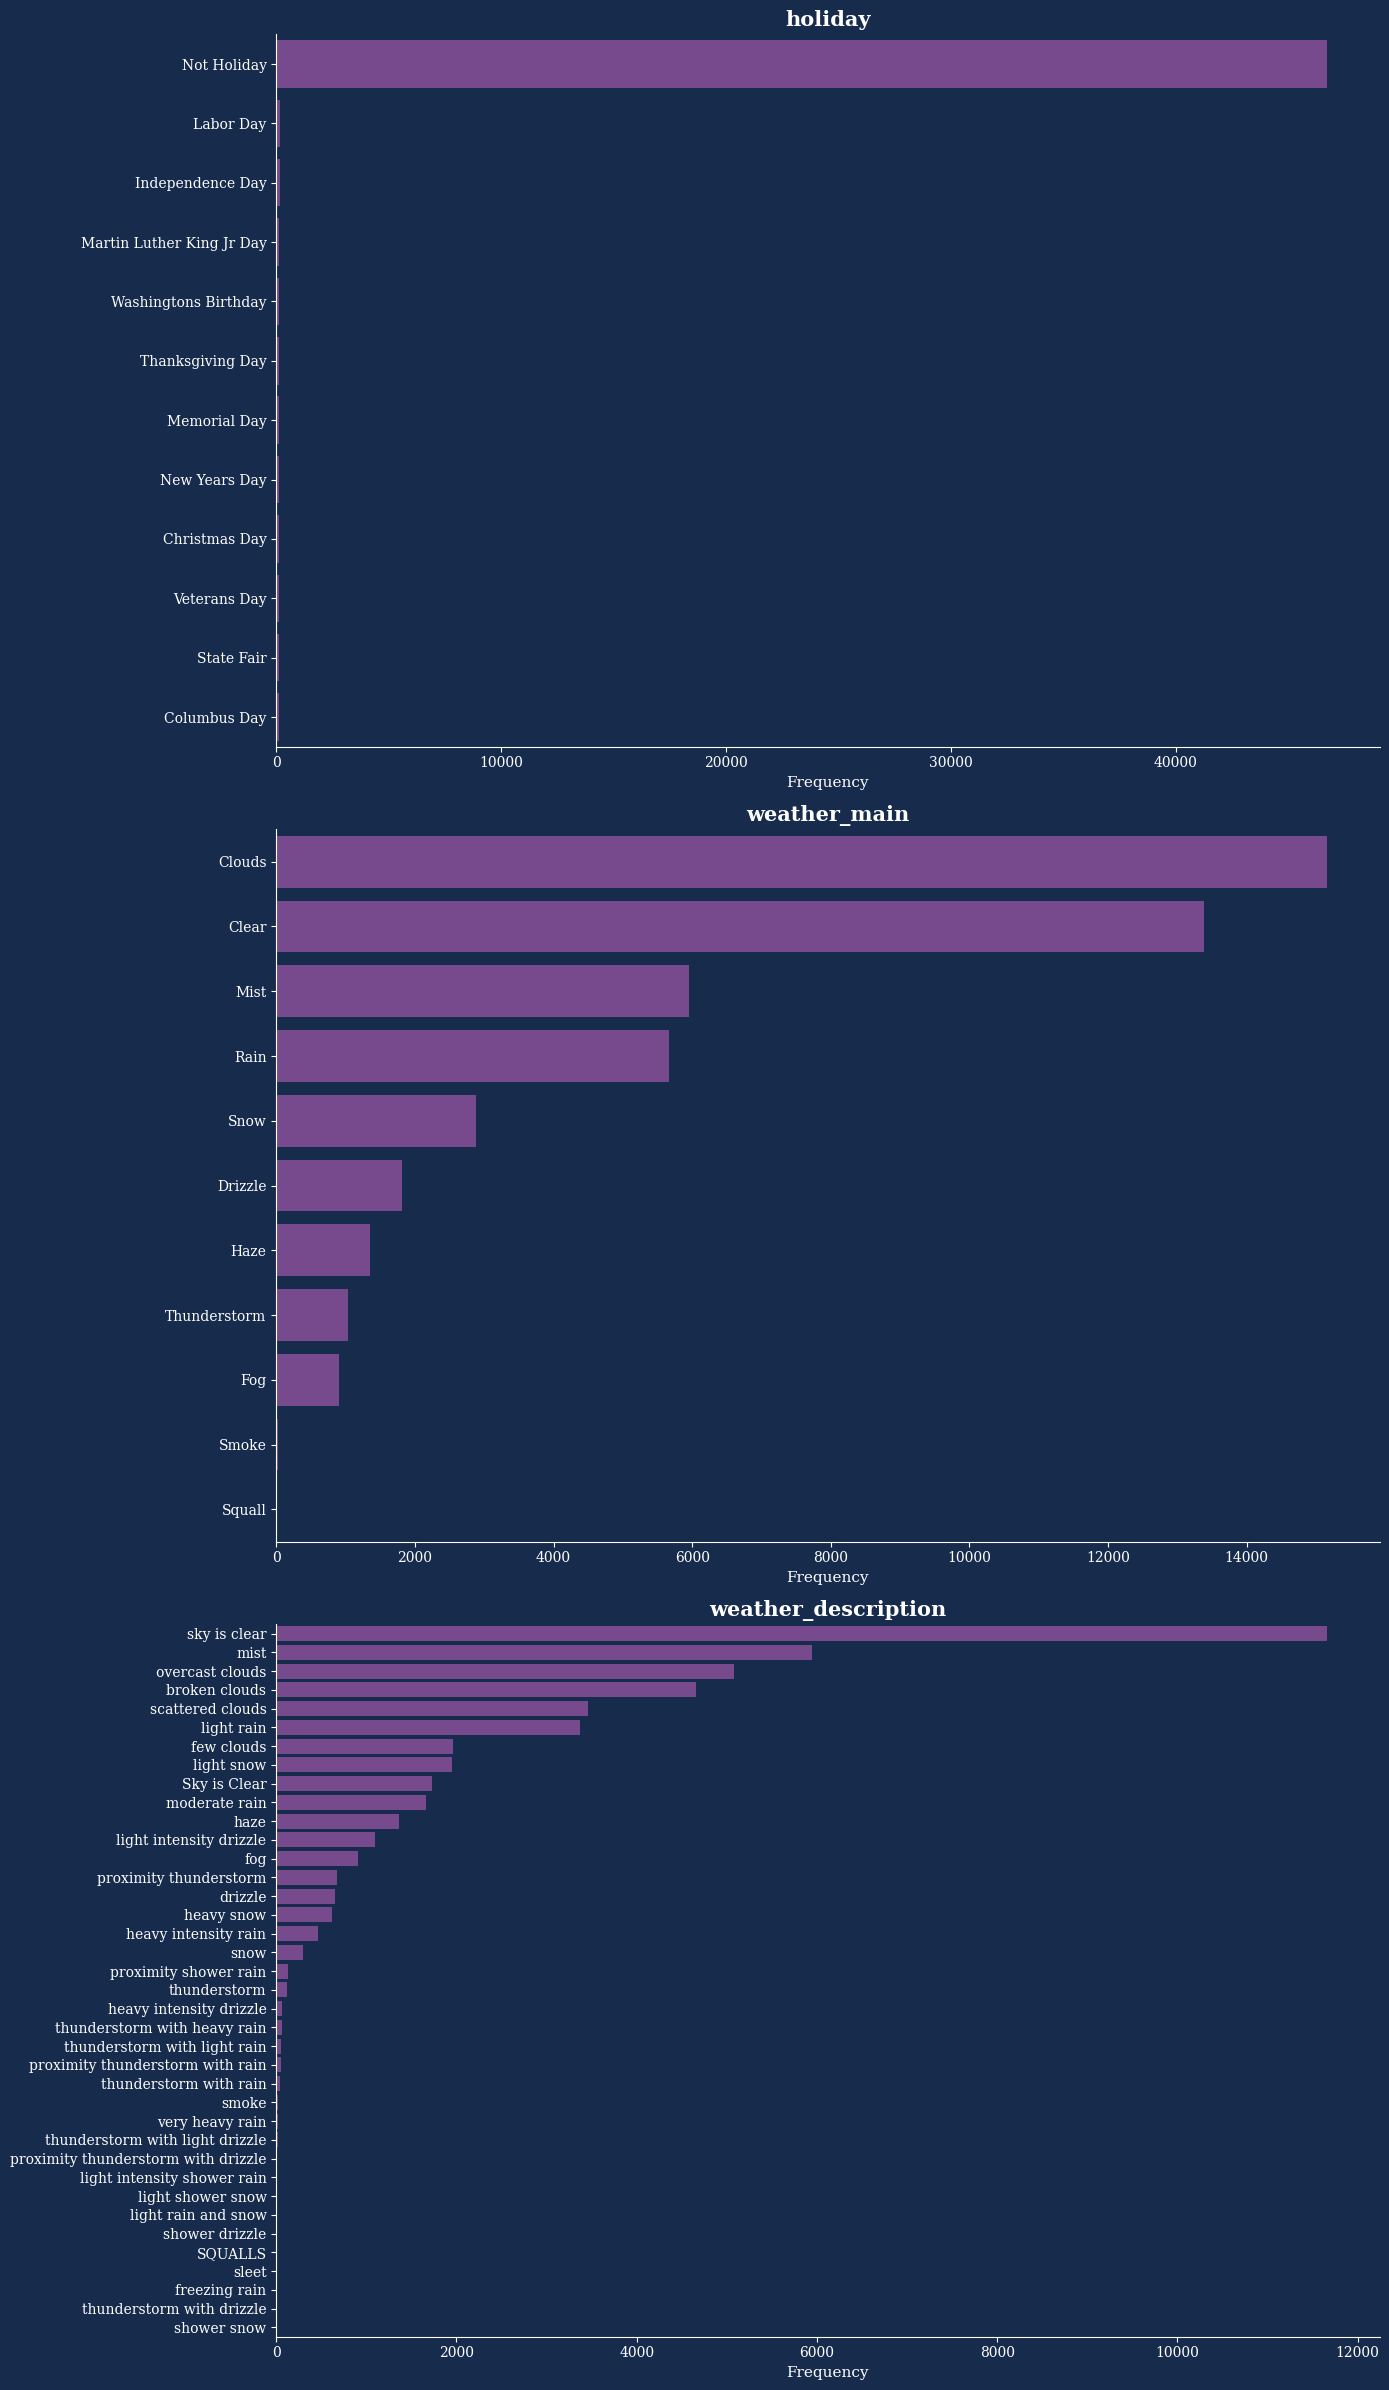

In [19]:
fig, axes = plt.subplots(
    nrows=len(cat_vars),
    ncols=1,
    figsize=(14, 8 * len(cat_vars)),
    facecolor="#172B4D"
)

axes = np.atleast_1d(axes)

for i, var in enumerate(cat_vars):

    counts = Traffic[var].value_counts()

    axes[i].set_facecolor("#172B4D")

    sns.barplot(
        x=counts.values,
        y=counts.index,
        ax=axes[i],
        color="#7B3F98"
    )

    axes[i].set_title(
        var,
        fontsize=15,
        fontweight='bold',
        fontfamily='serif',
        color='white'
    )

    axes[i].set_xlabel(
        'Frequency',
        fontsize=11,
        fontfamily='serif',
        color='white'
    )

    axes[i].set_ylabel('')

    axes[i].tick_params(
        axis='both',
        colors='white'
    )

    # Serif font for tick labels
    for label in axes[i].get_xticklabels():
        label.set_fontfamily('serif')

    for label in axes[i].get_yticklabels():
        label.set_fontfamily('serif')

    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['left'].set_color('white')
    axes[i].spines['bottom'].set_color('white')


plt.tight_layout()
plt.show()

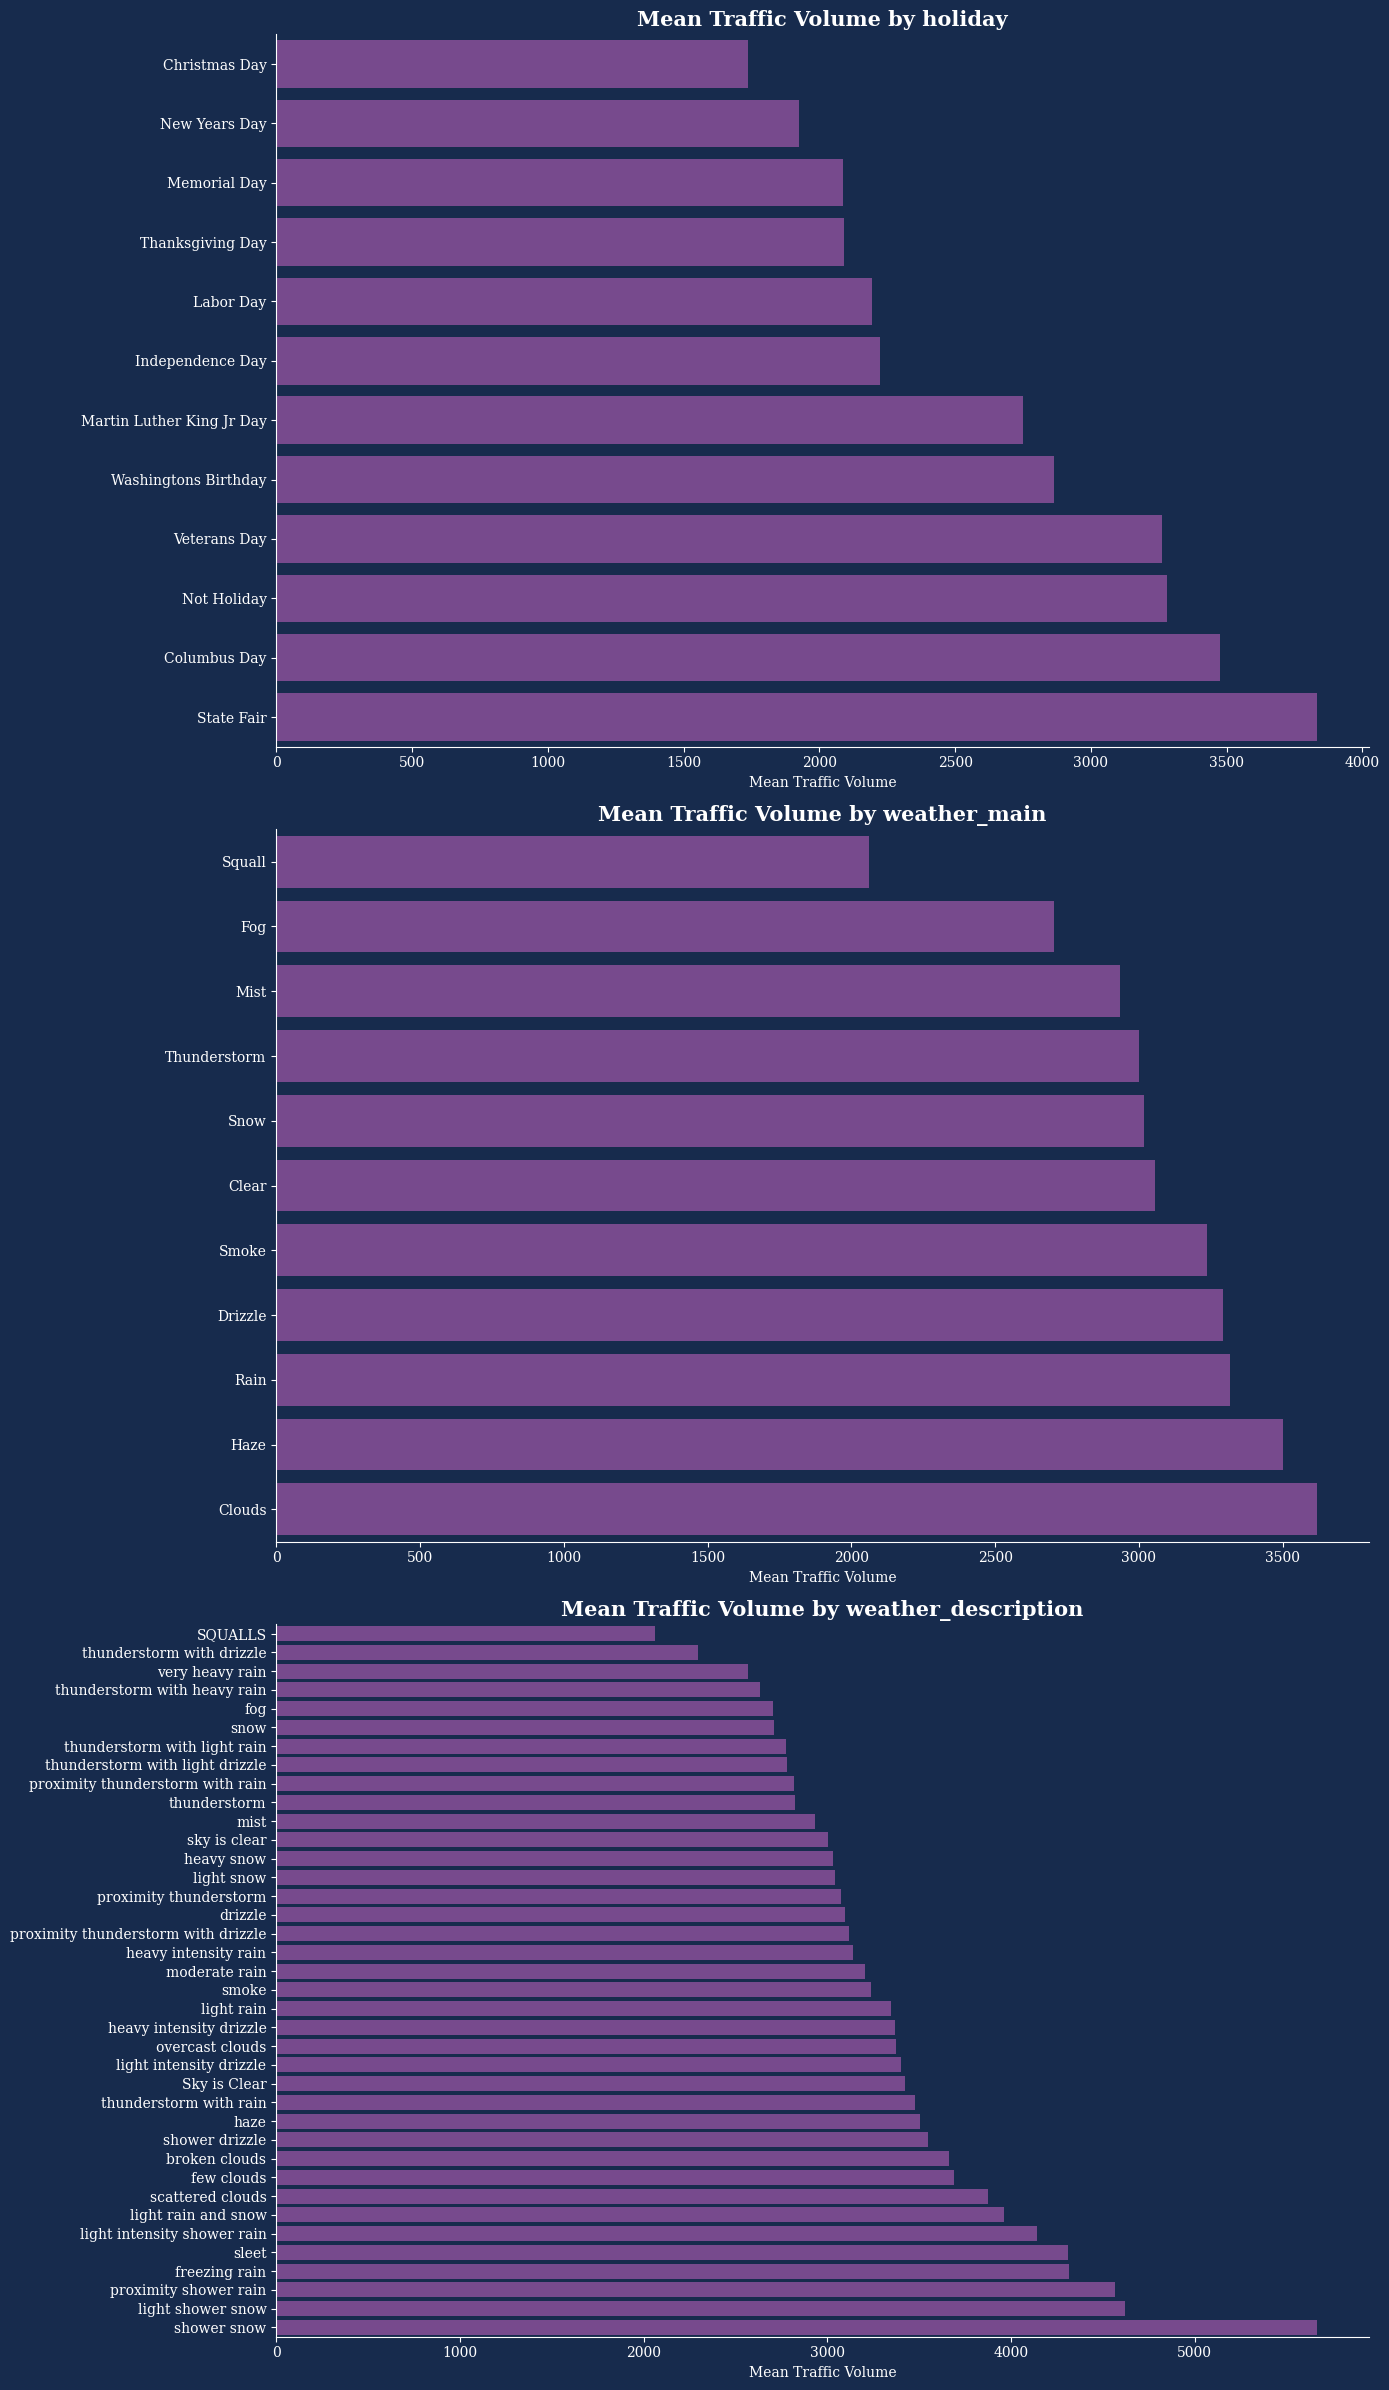

In [20]:
fig, axes = plt.subplots(
    nrows=len(cat_vars),
    ncols=1,
    figsize=(14, 8 * len(cat_vars)),
    facecolor="#172B4D"
)

axes = np.atleast_1d(axes)

for i, var in enumerate(cat_vars):

    mean_traffic = Traffic.groupby(var)['traffic_volume'].mean().sort_values()

    axes[i].set_facecolor("#172B4D")

    sns.barplot(
        x=mean_traffic.values,
        y=mean_traffic.index,
        ax=axes[i],
        color="#7B3F98"
    )

    axes[i].set_title(
        f'Mean Traffic Volume by {var}',
        fontsize=15,
        fontweight='bold',
        fontfamily='serif',
        color='white'
    )

    axes[i].set_xlabel(
        'Mean Traffic Volume',
        fontsize=10,
        fontfamily='serif',
        color='white'
    )

    axes[i].set_ylabel('')

    axes[i].tick_params(
        axis='both',
        colors='white'
    )

    for label in axes[i].get_xticklabels():
        label.set_fontfamily('serif')

    for label in axes[i].get_yticklabels():
        label.set_fontfamily('serif')

    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['left'].set_color('white')
    axes[i].spines['bottom'].set_color('white')


plt.tight_layout()
plt.show()

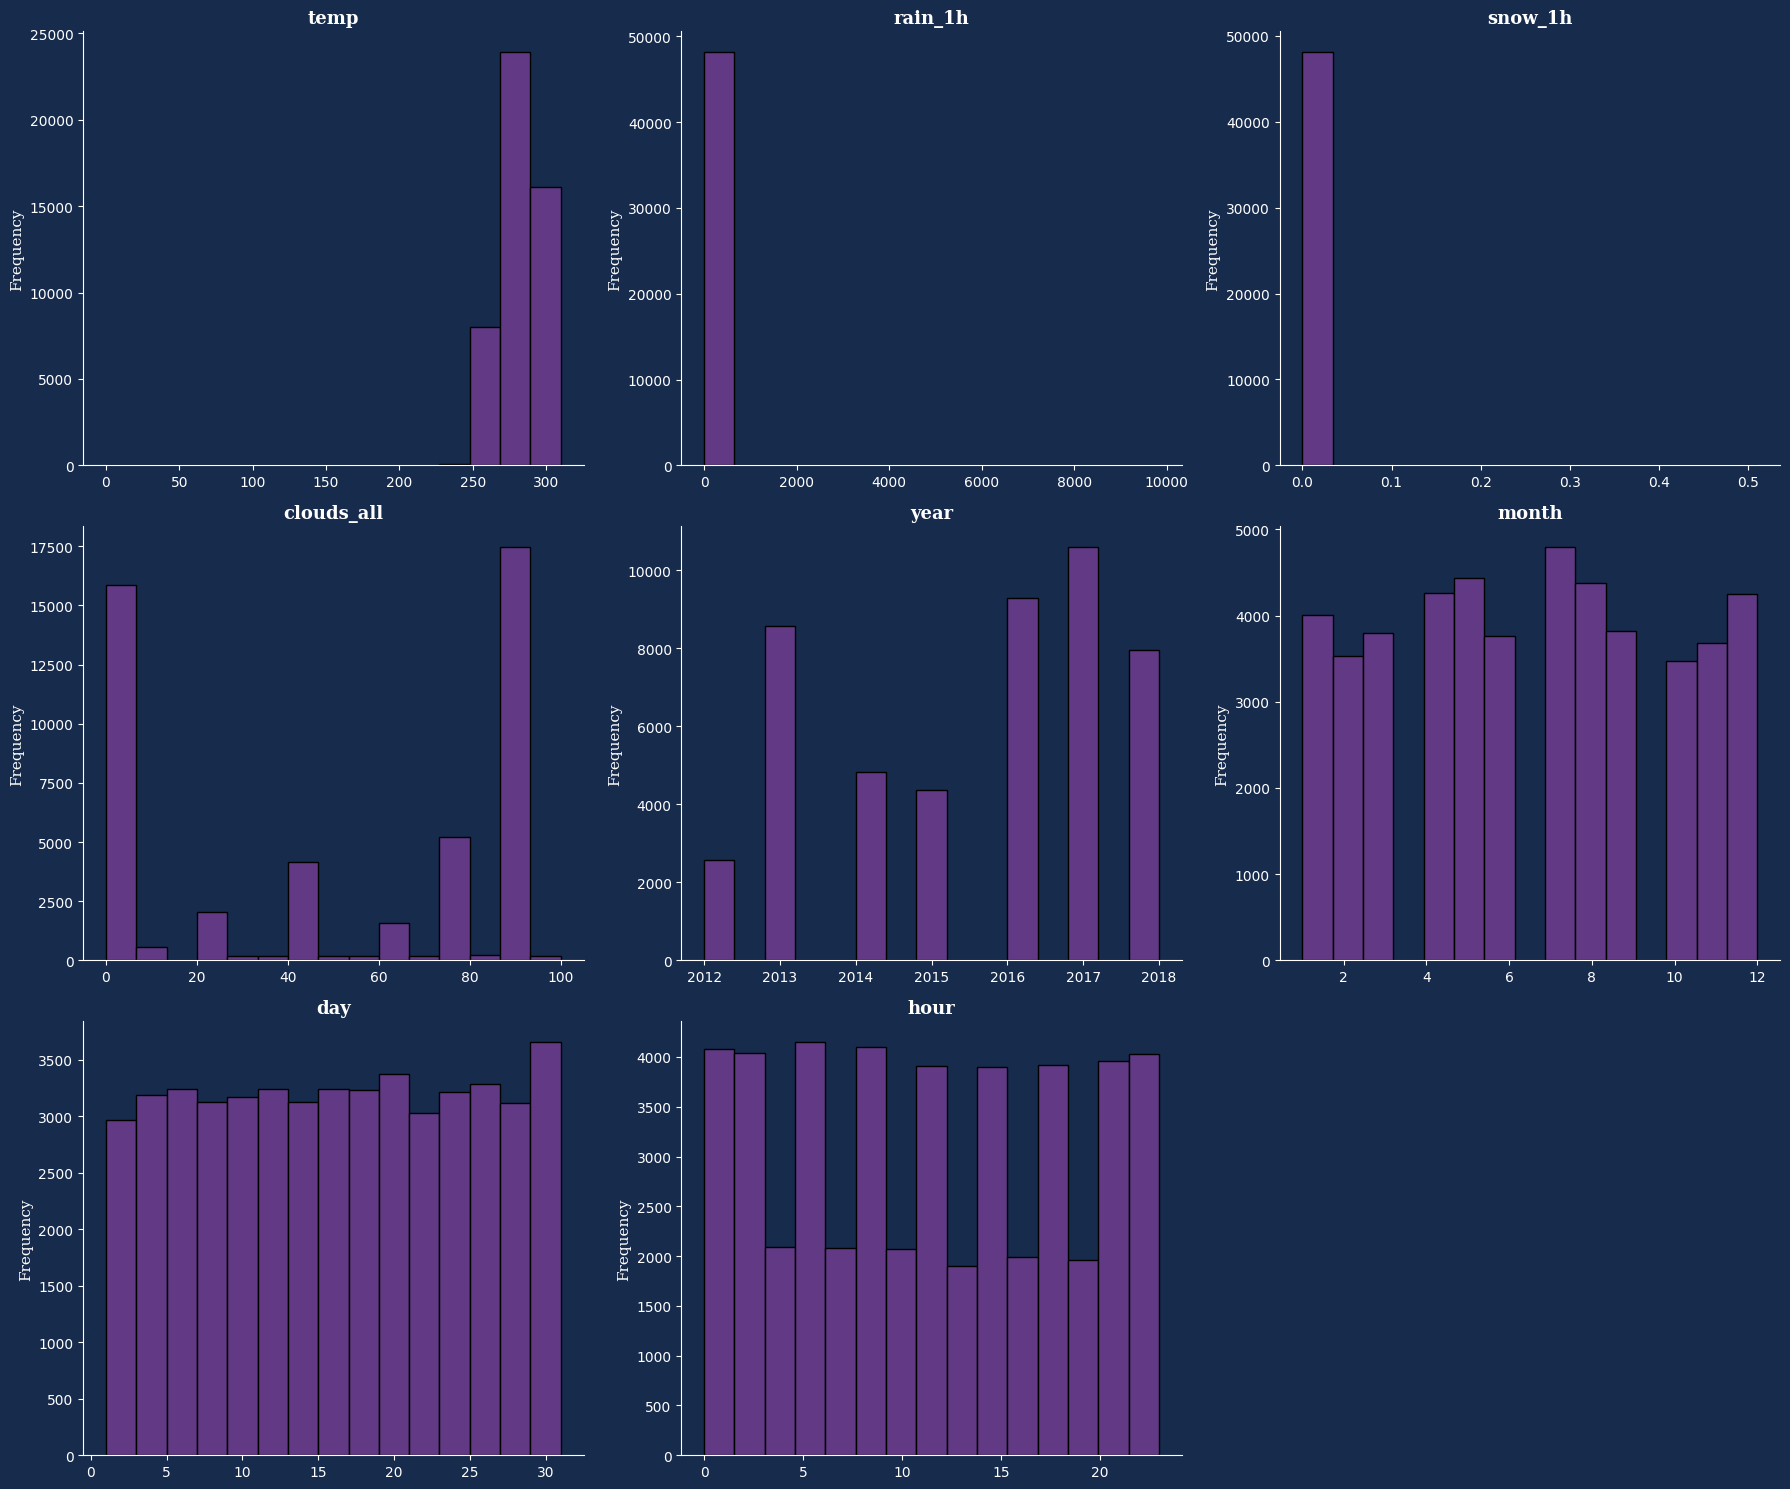

In [21]:
con_vars_ = [var for var in con_vars if var != 'traffic_volume']

n = len(con_vars_)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(18, 5 * nrows),
    facecolor="#172B4D"
)

axes = np.atleast_1d(axes).flatten()

for i, var in enumerate(con_vars_):

    ax = axes[i]
    ax.set_facecolor("#172B4D")

    sns.histplot(
        data=Traffic,
        x=var,
        bins=15,
        ax=ax,
        color="#7B3F98"
    )

    # Set x-axis according to the actual range of each variable
    xmin = Traffic[var].min()
    xmax = Traffic[var].max()
    padding = (xmax - xmin) * 0.05

    ax.set_xlim(xmin - padding, xmax + padding)

    ax.set_title(
        var,
        fontsize=13,
        fontweight='bold',
        fontfamily='serif',
        color='white'
    )

    ax.set_xlabel('')
    ax.set_ylabel(
        'Frequency',
        fontsize=11,
        fontfamily='serif',
        color='white'
    )

    ax.tick_params(axis='both', colors='white')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('white')
    ax.spines['bottom'].set_color('white')

for j in range(n, len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()
plt.show()

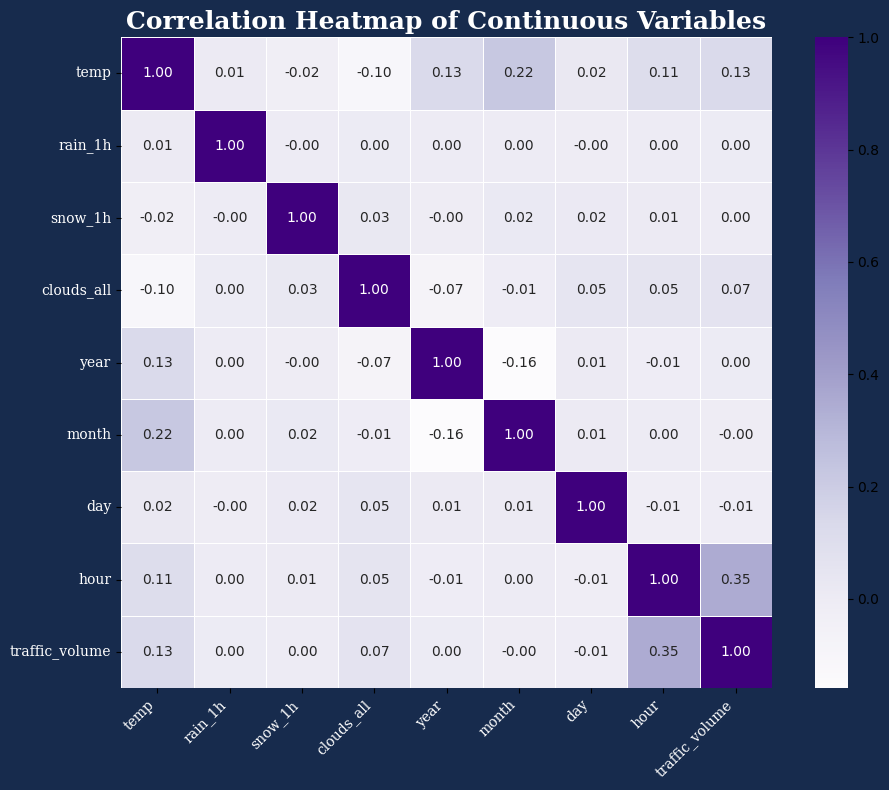

In [22]:
corr = Traffic[con_vars].corr()

plt.figure(figsize=(10, 8), facecolor="#172B4D")

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='Purples',
    linewidths=0.5,
    square=True
)

plt.title(
    'Correlation Heatmap of Continuous Variables',
    fontsize=18,
    fontweight='bold',
    fontfamily='serif',
    color='white'
)

plt.xticks(
    fontfamily='serif',
    color='white',
    rotation=45,
    ha='right'
)

plt.yticks(
    fontfamily='serif',
    color='white',
    rotation=0
)

plt.tight_layout()
plt.show()